# Chain

###  Build a chain with a chat-
                    - messages
                    - models
                    - tools
    - execute tool call in graph nodes.

<img src="../Images/chain_image.png" width="600" height="600">
                    

## Messages
- Messages are fundamental unit of context . It determines how LLms understand context.
- represent the input and output of models
- carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM.

## Messages are objects that contain:
 Role - Identifies the message type (e.g. system, user)
 Content - Represents the actual content of the message (like text, images, audio, documents, etc.)
 Metadata - Optional fields such as response information, message IDs, and token usage
LangChain provides a standard message type that works across all model providers, ensuring consistent behavior regardless of the model being called.

## Each message can be supplied with a few things:

    content - content of the message
    name - optionally, a message author
    response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [23]:
import sys
#sys.executable

In [1]:
from langchain_core.messages import AIMessage , HumanMessage, SystemMessage 

messages =[SystemMessage("you are a oacean mammals reasearch expert")]
messages.append(AIMessage(content=f"So you said you were researching ocean mammals?", name="Model"))
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for message in  messages:
    #print(message.content)
    message.pretty_print()

================================ System Message ================================

you are a oacean mammals reasearch expert
================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models
Use LLM models as chat models
messages act as input and system instruction 
- Connect API to use genai model
- use gemini-2.5-flash for free tier
- LangChain uses a different internal API version.
To make it work with Gemini 1.5 models, you MUST set:os.environ["GOOGLE_API_USE_V1"] = "true"


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [3]:
# Configure google‑genai (the new SDK)

from google import genai

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

result = llm.invoke(messages)
print(result.content)

Ah, a fantastic question! Orcas are truly magnificent creatures, and seeing them in the wild is an unforgettable experience. When it comes to the "best" place in the US, it really depends on what you're looking for, but a few regions stand out.

As an ocean mammal research expert, I can tell you that the **Pacific Northwest**, particularly the waters around **Washington State's San Juan Islands**, is historically the most famous and iconic place to see Orcas in the US. However, the dynamics have shifted a bit in recent years, so let's break it down:

### 1. The Pacific Northwest (Washington State: San Juan Islands & Puget Sound)

*   **Why it's famous:** This region is home to the **Southern Resident Killer Whales (SRKW)** – three distinct pods (J, K, and L) that primarily eat salmon. They are incredibly well-studied and have a strong cultural connection to the area.
*   **The Challenge:** The SRKW are critically endangered, facing severe threats from lack of salmon, vessel noise, and 

# Obtain Metadata

In [5]:
result

AIMessage(content='Ah, a fantastic question! Orcas are truly magnificent creatures, and seeing them in the wild is an unforgettable experience. When it comes to the "best" place in the US, it really depends on what you\'re looking for, but a few regions stand out.\n\nAs an ocean mammal research expert, I can tell you that the **Pacific Northwest**, particularly the waters around **Washington State\'s San Juan Islands**, is historically the most famous and iconic place to see Orcas in the US. However, the dynamics have shifted a bit in recent years, so let\'s break it down:\n\n### 1. The Pacific Northwest (Washington State: San Juan Islands & Puget Sound)\n\n*   **Why it\'s famous:** This region is home to the **Southern Resident Killer Whales (SRKW)** – three distinct pods (J, K, and L) that primarily eat salmon. They are incredibly well-studied and have a strong cultural connection to the area.\n*   **The Challenge:** The SRKW are critically endangered, facing severe threats from lack

In [6]:
result.response_metadata

{'finish_reason': 'STOP',
 'model_name': 'gemini-2.5-flash',
 'safety_ratings': [],
 'model_provider': 'google_genai'}

In [7]:
result.usage_metadata

{'input_tokens': 57,
 'output_tokens': 2671,
 'total_tokens': 2728,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 1347}}

# Tool Binding and Calling
- Tools are useful whenever you want a model to interact with external systems.
- When tool is binded to an llm, model get aware of input schema or payload of that perticular tool
- based on the user input, modle decided to call the tool and provides the api i/p as tool schema
    i.e, llm o/p to the tool -> tool in/p schema or payload



## Task:  call a function to multiply two numbers

In [8]:
# createa tool function with description
def multiply(a: int,b: int)->int:
    """ Multiply provided two numbers i,e, a and b 
    args: 
    a = first a int
    b = second int 
    result is 'c' which is an int
    """    
    c= a*b
    return c

# bind the tool function
llm_with_tool = llm.bind_tools([multiply])

tool_call = llm_with_tool.invoke([HumanMessage(role ="user" , content="What is the result of multiplying 23 and 45" , name = "Diya")])    
    

In [9]:
tool_call

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 23, "b": 45}'}, '__gemini_function_call_thought_signatures__': {'7e002ac7-14e5-462c-8297-024cf7a85240': 'CrMCAb4+9vuA0n+OeO6WhYRmae/5INwLDdF8Wh01/S/5mXrPvCeHLHSuN2nABSkNC1ie0f0H3ANYx9ot6HKXKk7Q9H/iUdVsktXC9cukSgc6343/WapOsSUW+1Lgh3p7Qsf+uW2eptCUxf57onkTyMIQlRJcG+fjuPLl+6JTMZZi14oO7dzhWwxNMZ+NWa5q94DVgW6Mj91dqnAf6qqQLVMQRtrtbnK8v6E2V+xVMFtdeTgvPDCcN35bElt5vWNVWJIO3mhC8+u2FD045G3PvEEfMppgHxav6dAIvBRRWEyeZPC9fmFxCv6N3D6IrxXGO40KJy/NA5Sq6iSnw2c+g4U9UJo3KkRpe/KbA2/IMiZenzJFDzx3hiTjd7QOVX/u0iTQvbzDDq4WUQDMh6+S6IZAUg62/g=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8dec-9cbf-7523-83e7-1063f943d010-0', tool_calls=[{'name': 'multiply', 'args': {'a': 23, 'b': 45}, 'id': '7e002ac7-14e5-462c-8297-024cf7a85240', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 97

In [10]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 23, 'b': 45},
  'id': '7e002ac7-14e5-462c-8297-024cf7a85240',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use  [messages](https://docs.langchain.com/oss/python/langchain/overview#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [11]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

# Reducers
Reducers specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

In [12]:
from typing import Annotated
from langgraph.graph.message import add_messages

class messagesState(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

#Example

In [13]:
old_message = [AIMessage(role="Model" , content = "How can I help you?" , name ="AI"),
               HumanMessage(role ="User" , content ="I would like to learn about Marine Biologuy" , name ="Diya")
                            ]
new_message = AIMessage(role="Model" , content = "Sure, WHat are would you like to focus on eg: Speciese, Evironment etc?" , name = "AI")

add_messages = (old_message , new_message)
add_messages


([AIMessage(content='How can I help you?', additional_kwargs={}, response_metadata={}, name='AI', tool_calls=[], invalid_tool_calls=[], role='Model'),
  HumanMessage(content='I would like to learn about Marine Biologuy', additional_kwargs={}, response_metadata={}, name='Diya', role='User')],
 AIMessage(content='Sure, WHat are would you like to focus on eg: Speciese, Evironment etc?', additional_kwargs={}, response_metadata={}, name='AI', tool_calls=[], invalid_tool_calls=[], role='Model'))

# Prebuilt MessagesState
Since having a list of messages in graph state is so common, LangGraph has a pre-built MessagesState!

MessagesState is defined:
- With a pre-build single messages key
- This is a list of AnyMessage objects
- It uses the add_messages reducer

We'll usually use MessagesState because it is less verbose than defining a custom TypedDict, as shown above.

In [14]:
from langgraph.graph import MessagesState

class message_state(MessagesState):
    pass

# create a graph with message state

In [15]:
# to create a mermaid diagragram import display and image
from IPython.display import display, Image
# to generate a graph
from langgraph.graph import StateGraph, START , END

''' create a node function

def tool_calling_llm(state:MessagesState):
    return { "messages" : [llm_with_tool.invoke(state["messages"])]}
'''
def tool_calling_llm(state: MessagesState):
    response = llm_with_tool.invoke(state["messages"])
    print(f"response_printed: {response}")
    print(f"state_Message_printed: {state['messages']}")
    return {"messages": [response]}


# Build graph
builder = StateGraph(MessagesState)
builder.add_node("Tool_Calling_Node" , tool_calling_llm)
builder.add_edge(START , "Tool_Calling_Node")
builder.add_edge("Tool_Calling_Node", END)

graph = builder.compile()

#graph.invoke({})

# View graph


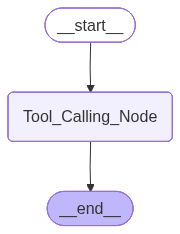

In [16]:
display(Image(graph.get_graph().draw_mermaid_png()))

## invoke llm without calling tools

##### Note: Check printed state messages  and response from node 1

In [17]:
result = graph.invoke({"messages": [HumanMessage(content="Hello!what can you do for me?")]})
result

response_printed: content='I can multiply two numbers for you. Please provide two numbers you would like to multiply.' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d8dec-eca9-7d10-8c16-cb41ce475af8-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 93, 'output_tokens': 18, 'total_tokens': 111, 'input_token_details': {'cache_read': 0}}
state_Message_printed: [HumanMessage(content='Hello!what can you do for me?', additional_kwargs={}, response_metadata={}, id='6c9ba41e-8a70-4602-8b50-14c70118ceea')]


{'messages': [HumanMessage(content='Hello!what can you do for me?', additional_kwargs={}, response_metadata={}, id='6c9ba41e-8a70-4602-8b50-14c70118ceea'),
  AIMessage(content='I can multiply two numbers for you. Please provide two numbers you would like to multiply.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8dec-eca9-7d10-8c16-cb41ce475af8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 93, 'output_tokens': 18, 'total_tokens': 111, 'input_token_details': {'cache_read': 0}})]}

In [18]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!what can you do for me?
================================== Ai Message ==================================

I can multiply two numbers for you. Please provide two numbers you would like to multiply.


## Invoke tool

In [49]:
result = graph.invoke({"messages": [HumanMessage(content="Alright ,  Multiple 7846 and 97645 and give me  the result")]})
tool_calls = result["messages"][-1].tool_calls
tool_calls

response_printed: content='' additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 7846, "b": 97645}'}, '__gemini_function_call_thought_signatures__': {'58c5bc86-73d0-427e-8190-5f49c717ecaf': 'CooDAb4+9vuep23DQTQ6HBmWWj5cctSXBMrHOHddGu2MQ3CHJmdoqZkNO8seX+1tEOzq1vG5BJCdJF5WvnXtntkvlePT95ETpvwvkWej7C0KQXv3/11Ia4AV6wWFevPTM76K+oRW4oFg5LxdEdtIZWYrXVp0tGEgHuPEFoNZO5GyjJ5/YA4g3tyOHH0T0InehfPoEmnXHT8RLSyZilG0hqTEYraSXeR3jiIq91jY+njLHHmrN20XIS6RejRuZgC4MdRWsHv6nhMF/fH0AVEfz6gO3YeNmg9FRicTQ5ElLk87IIo+QJFrBBaEgWnX6fns5nifCwk6V3voT/sm5TwP1rMy5NFoAgcFIb3B15NLrOJc5yq378hZsW90bYUg4zVP5HmeY02XfwJx9FzComWSBYexlmTRtPOrJuK2ynhbc3N1Bg/Ia6zvEEBLIOQvuk7S11eYJCMY03bwujqjM3o29xJ+FKTtqsSmEFLOvRXjlNolKjBn/uI7Sq+NtLUk1d3SUlKGc50Fy3IDXlgxjA=='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d8e89-f5bd-7bc2-b4c8-7a6e2ce50391-0' tool_calls=[{'name': 'multiply', 'args': {'a': 7846, 'b': 9764

[{'name': 'multiply',
  'args': {'a': 7846, 'b': 97645},
  'id': '58c5bc86-73d0-427e-8190-5f49c717ecaf',
  'type': 'tool_call'}]

In [20]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Alright ,  Multiple 7846 and 97645 and give me  the result
================================== Ai Message ==================================
Tool Calls:
  multiply (13b11dda-9705-4e81-bf02-5f9bc43f3f0a)
 Call ID: 13b11dda-9705-4e81-bf02-5f9bc43f3f0a
  Args:
    a: 7846
    b: 97645


In [51]:
for calls in tool_calls:
    print(calls)

{'name': 'multiply', 'args': {'a': 7846, 'b': 97645}, 'id': '58c5bc86-73d0-427e-8190-5f49c717ecaf', 'type': 'tool_call'}


# Create a node to execute tool

In [68]:
from langchain_core.messages import ToolMessage
def tool_execute(state: MessagesState):
    #extract tool calls from state messages
    last = state['messages'][-1].tool_calls
    print(f"Last_State{last}")
    #result = []
    #extract the dicts from the list 
    for call in last:
        if call['name'] == "multiply" :
            result = multiply(call['args']['a'],call['args']['b'])
            print(f"\n Result_printed : {result}")
            return {'messages' : [ToolMessage(content=str(result), tool_call_id = call['id'])]}
        
        else:
            return {'messages':[]}
            

        
        
        
        


In [65]:

            
''' 
def execute_tools(state):
    last = state["messages"][-1]

    if not last.tool_calls:
        return {"messages": []}  # no tool call

    results = []
    for call in last.tool_calls:
        if call["name"] == "multiply":
            a = call["args"]["a"]
            b = call["args"]["b"]
            result = multiply(a, b)
            results.append(
                ToolMessage(
                    content=str(result),
                    tool_call_id=call["id"]
                )
            )

    return {"messages": results}

'''
        
        
        
        


' \ndef execute_tools(state):\n    last = state["messages"][-1]\n\n    if not last.tool_calls:\n        return {"messages": []}  # no tool call\n\n    results = []\n    for call in last.tool_calls:\n        if call["name"] == "multiply":\n            a = call["args"]["a"]\n            b = call["args"]["b"]\n            result = multiply(a, b)\n            results.append(\n                ToolMessage(\n                    content=str(result),\n                    tool_call_id=call["id"]\n                )\n            )\n\n    return {"messages": results}\n\n'

# Set graph with condition

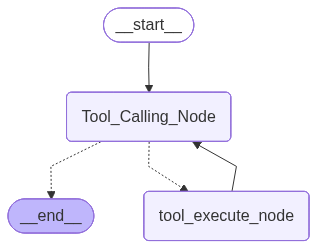

In [80]:
builder2  = StateGraph(MessagesState)

# add nodes
builder2.add_node("Tool_Calling_Node" , tool_calling_llm)
builder2.add_node("tool_execute_node" , tool_execute)

# add edges
builder2.set_entry_point("Tool_Calling_Node")
#builder2.add_edge("Tool_Calling_Node", "tool_execute_node")

# set condition
builder2.add_conditional_edges("Tool_Calling_Node",lambda state: 'tool_execute_node' if state['messages'][-1].tool_calls else END , {'tool_execute_node':'tool_execute_node' , END:END })
builder2.add_edge('tool_execute_node','Tool_Calling_Node')

gragh2 = builder2.compile()
builder2.compile()

In [81]:
result = gragh2.invoke({"messages": [HumanMessage(content="Multiple 7846 and 97645 and give me  the result")]})


response_printed: content='' additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 7846, "b": 97645}'}, '__gemini_function_call_thought_signatures__': {'18b83711-966d-49e6-b624-b6878767018f': 'CqYCAb4+9vsaQCDT8IHSB4IMnASqogbwExo7RDx4CErNmanYgPEDbpGgvek7Gc4BkmAYyN+BQ3Tt0TcgJ6NqyCiRxOloDmntPm818gWgz+jgipqTHnUIR6wNCbpywuD3uLFe5O4TNSxsKHt5DCRoyMNVS0gg/eCdwznBMz7hxZEA7OVkLhX2qlYiupwEY/k+/6DU61ppGs8kFpVQvN4i3vPlNHCD8Nt+h+EttuGkdFWe6/MTzJNGg/Y5yY9hnq2TEX/E3HIQKkv2CaTvoY3DWUGF46u+CZ3NsP2LPgfDC3V38DIbldMcp8X9NmoSmryiQqkrx4MquNKwd6QH6UgyX5br2h9kEqYLT8B1STBqv7OMzjojFGnKLyncJlK6HxUW4SbhN2Muh2c4'}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d8ead-e54a-7490-9244-cde641a0ebc9-0' tool_calls=[{'name': 'multiply', 'args': {'a': 7846, 'b': 97645}, 'id': '18b83711-966d-49e6-b624-b6878767018f', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 103, 'outp

In [84]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiple 7846 and 97645 and give me  the result
================================== Ai Message ==================================
Tool Calls:
  multiply (18b83711-966d-49e6-b624-b6878767018f)
 Call ID: 18b83711-966d-49e6-b624-b6878767018f
  Args:
    a: 7846
    b: 97645
================================= Tool Message =================================

766122670
================================== Ai Message ==================================

The result of multiplying 7846 and 97645 is 766122670.
